In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
data=pd.read_csv('cleaned data.csv')
df=pd.DataFrame(data)

Dataset overview


In [3]:
df.describe()

,EmployeeNumber,Age,Attrition,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.161224,9.192517,2.912925,2.721769,2.729932,2.063946,2.728571,6502.931293,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.367863,8.106864,1.024165,1.093082,0.711561,1.106940,1.102846,4707.956783,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2911.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,7.000000,3.000000,3.000000,3.000000,2.000000,3.000000,4919.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,14.000000,4.000000,4.000000,3.000000,3.000000,4.000000,8379.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,29.000000,5.000000,4.000000,4.000000,5.000000,4.000000,19999.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [4]:
df.shape

(1470, 32)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeNumber            1470 non-null   int64 
 1   Age                       1470 non-null   int64 
 2   Attrition                 1470 non-null   int64 
 3   BusinessTravel            1470 non-null   object
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  JobInvolvement            1470 non-null   int64 
 11  JobLevel                  1470 non-null   int64 
 12  JobRole                   1470 non-null   object
 13  JobSatisfaction           1470 non-null   int64 
 14  MaritalStatus           

In [6]:
df['Attrition'].value_counts()


Attrition
0    1233
1     237
Name: count, dtype: int64

In [7]:
df['Attrition'].value_counts()*100/len(df)


Attrition
0    83.877551
1    16.122449
Name: count, dtype: float64

In [8]:
print(df['BusinessTravel'].value_counts())


BusinessTravel
rare        1043
Frequent     277
Non          150
Name: count, dtype: int64


In [9]:
print(df['Department'].value_counts())

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


In [10]:
print(df['JobRole'].value_counts())

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64


In [11]:
print(df['Gender'].value_counts())

Gender
Male      882
Female    588
Name: count, dtype: int64


Exploring attrition factors

In [12]:
df.groupby('Attrition')['MonthlyIncome'].mean()

Attrition
0    6832.739659
1    4787.092827
Name: MonthlyIncome, dtype: float64

In [13]:
stayed=df[df['Attrition']==0]['MonthlyIncome']
left=df[df['Attrition']==1]['MonthlyIncome']
t_stat,p_value=stats.ttest_ind(stayed,left)
print(t_stat,p_value)

6.203935765608938 7.14736398535381e-10


In [14]:
df.groupby(['Attrition','BusinessTravel']).size()

Attrition  BusinessTravel
0          Frequent          208
           Non               138
           rare              887
1          Frequent           69
           Non                12
           rare              156
dtype: int64

In [15]:
df.groupby(['Attrition','Department']).size()

Attrition  Department            
0          Human Resources            51
           Research & Development    828
           Sales                     354
1          Human Resources            12
           Research & Development    133
           Sales                      92
dtype: int64

In [16]:
df.groupby(['Attrition','JobRole']).size()

Attrition  JobRole                  
0          Healthcare Representative    122
           Human Resources               40
           Laboratory Technician        197
           Manager                       97
           Manufacturing Director       135
           Research Director             78
           Research Scientist           245
           Sales Executive              269
           Sales Representative          50
1          Healthcare Representative      9
           Human Resources               12
           Laboratory Technician         62
           Manager                        5
           Manufacturing Director        10
           Research Director              2
           Research Scientist            47
           Sales Executive               57
           Sales Representative          33
dtype: int64

In [17]:
df.groupby(['Attrition','OverTime']).size()

Attrition  OverTime
0          0           944
           1           289
1          0           110
           1           127
dtype: int64

In [18]:
stayed=df[df['Attrition']==0]['OverTime']
left=df[df['Attrition']==1]['OverTime']
t_stat,p_value=stats.ttest_ind(stayed,left)
print(t_stat,p_value)

-9.729155002966676 1.0092540336563068e-21


In [19]:
df.groupby(['Attrition','JobSatisfaction']).size()

Attrition  JobSatisfaction
0          1                  223
           2                  234
           3                  369
           4                  407
1          1                   66
           2                   46
           3                   73
           4                   52
dtype: int64

In [20]:
stayed=df[df['Attrition']==0]['JobSatisfaction']
left=df[df['Attrition']==1]['JobSatisfaction']
t_stat,p_value=stats.ttest_ind(stayed,left)
print(t_stat,p_value)

3.9862267630568273 7.043066741731151e-05


In [21]:
df.groupby(['Attrition','Gender']).size()

Attrition  Gender
0          Female    501
           Male      732
1          Female     87
           Male      150
dtype: int64

In [22]:
df.groupby(['Attrition','MaritalStatus']).size()

Attrition  MaritalStatus
0          Divorced         294
           Married          589
           Single           350
1          Divorced          33
           Married           84
           Single           120
dtype: int64

In [23]:
df.groupby(['Attrition','Salary_hike_Group']).size()

Attrition  Salary_hike_Group
0          high                  98
           low                  769
           medium               366
1          high                  25
           low                  150
           medium                62
dtype: int64

 Demographic Analysis


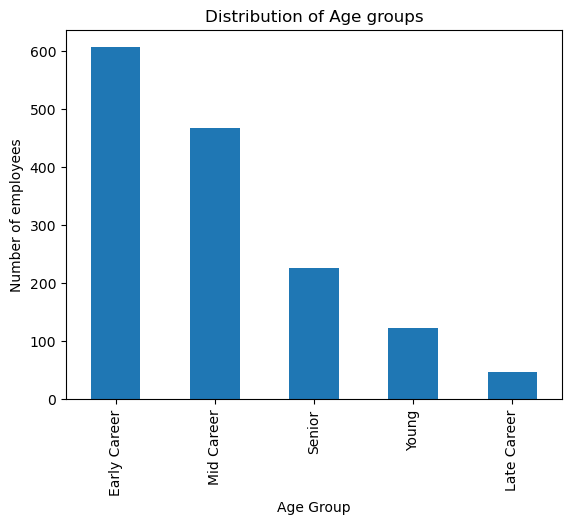

In [24]:
df['Age Group'].value_counts().plot(kind='bar')
plt.xlabel('Age Group')
plt.ylabel('Number of employees')
plt.title('Distribution of Age groups')
plt.show()

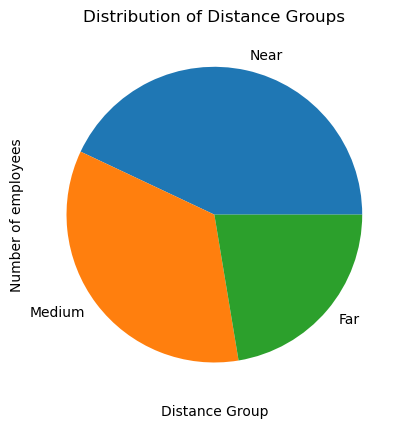

In [25]:
df['Distance Group'].value_counts().plot(kind='pie')
plt.xlabel('Distance Group')
plt.ylabel('Number of employees')
plt.title('Distribution of Distance Groups')
plt.show()

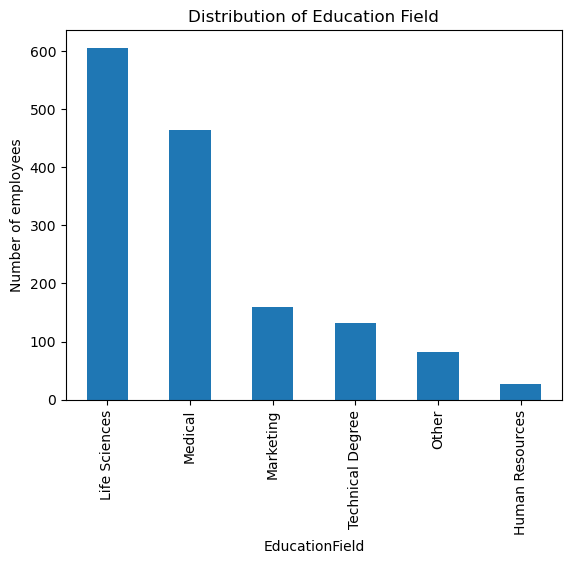

In [26]:
df['EducationField'].value_counts().plot(kind='bar')
plt.xlabel('EducationField')
plt.ylabel('Number of employees')
plt.title('Distribution of Education Field')
plt.show()

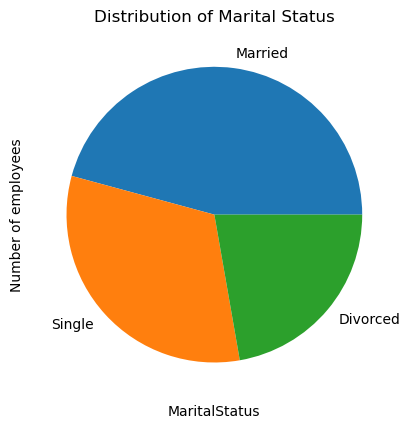

In [27]:
df['MaritalStatus'].value_counts().plot(kind='pie')
plt.xlabel('MaritalStatus')
plt.ylabel('Number of employees')
plt.title('Distribution of Marital Status')
plt.show()